# Overfitting & Generalization

过拟合不是玄学，而是偏差-方差分解的必然结果。本课推导分解公式，用多项式拟合模拟 bias²/variance 随复杂度的变化，并画出学习曲线。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 偏差-方差分解


对固定数据点 $x$，记真值 $y = f(x) + \epsilon$（噪声 $\mathrm{Var}[\epsilon] = \sigma^2$），模型估计 $\hat f(x)$（对**数据集**取期望）：

$$\mathbb{E}\big[(y - \hat f)^2\big] = \underbrace{\big(\mathbb{E}[\hat f] - f\big)^2}_{\text{偏差}^2} + \underbrace{\mathrm{Var}[\hat f]}_{\text{方差}} + \underbrace{\sigma^2}_{\text{不可约噪声}}$$

**推导**：$y - \hat f = (f - \mathbb{E}[\hat f]) + (\mathbb{E}[\hat f] - \hat f) + \epsilon$，三项交叉期望为零（$\epsilon$ 零均值且独立）。

- 简单模型：偏差大（拟合不足）、方差小
- 复杂模型：偏差小、方差大（拟合噪声）
- 总误差在中间某复杂度取最小——这就是"该多复杂"的答案


次数 | 偏差² | 方差 | 总误差(含噪声)
   1  | 0.1687 | 0.0167 | 0.2253
   3  | 0.0033 | 0.0083 | 0.0517
   6  | 0.0001 | 0.0779 | 0.1180
   9  | 0.0697 | 9.5693 | 9.6790


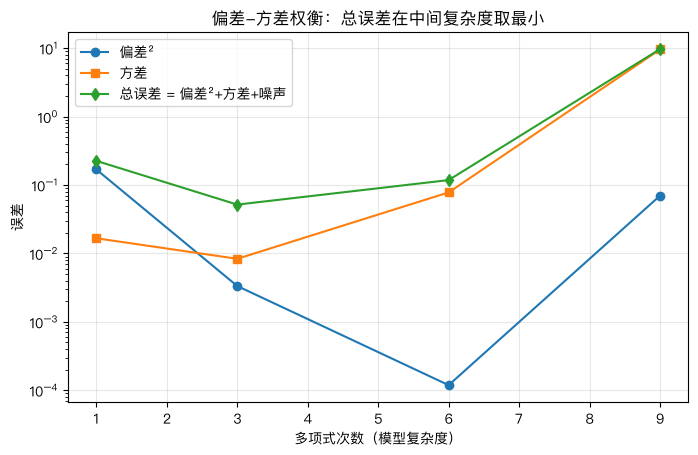

In [2]:
rng = np.random.default_rng(0)
x_grid = np.linspace(-3, 3, 200)
f_true = np.sin(x_grid)
degrees = [1, 3, 6, 9]
bias2, variance = [], []
for d in degrees:
    preds = []
    for _ in range(150):
        xs = rng.uniform(-3, 3, 30)
        ys = np.sin(xs) + 0.2*rng.standard_normal(30)
        coeffs = np.polyfit(xs, ys, d)
        preds.append(np.polyval(coeffs, x_grid))
    preds = np.array(preds)
    bias2.append(((preds.mean(0) - f_true)**2).mean())
    variance.append(preds.var(0).mean())

bias2 = np.array(bias2); variance = np.array(variance)
total = bias2 + variance + 0.2**2
print("次数 | 偏差² | 方差 | 总误差(含噪声)")
for d, b, v, t in zip(degrees, bias2, variance, total):
    print(f"  {d:2d}  | {b:.4f} | {v:.4f} | {t:.4f}")

plt.figure(figsize=(8, 4.8))
plt.semilogy(degrees, bias2, 'o-', label='偏差²')
plt.semilogy(degrees, variance, 's-', label='方差')
plt.semilogy(degrees, total, 'd-', label='总误差 = 偏差²+方差+噪声')
plt.xlabel('多项式次数（模型复杂度）'); plt.ylabel('误差')
plt.title('偏差-方差权衡：总误差在中间复杂度取最小')
plt.legend(); plt.grid(alpha=0.3)


## 2. 可视化：三种复杂度下的拟合


灰线 = 不同数据集上的拟合 → 次数 9 的灰线彼此差异巨大（方差大）


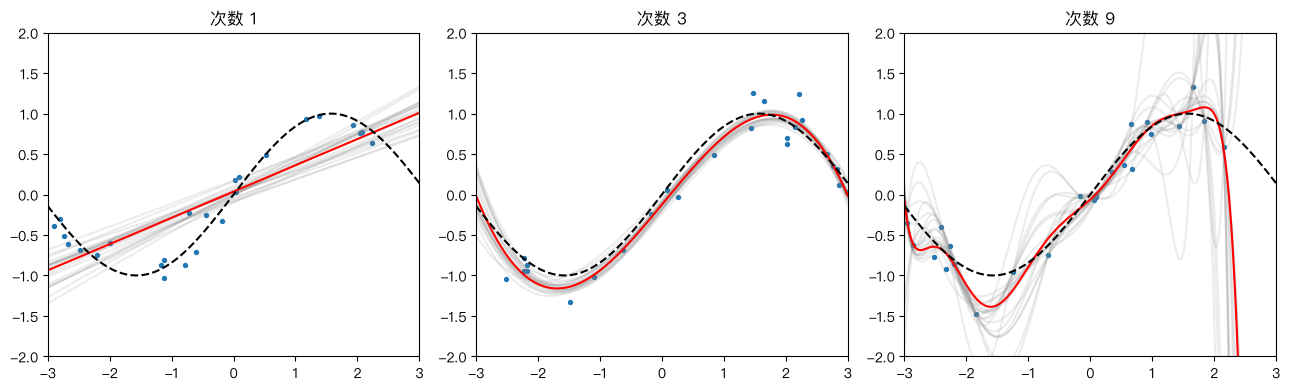

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, d in zip(axes, [1, 3, 9]):
    xs = rng.uniform(-3, 3, 25)
    ys = np.sin(xs) + 0.2*rng.standard_normal(25)
    for trial in range(20):                    # 多次重采样数据集
        idx = rng.choice(len(xs), len(xs), replace=True)
        w = np.polyfit(xs[idx], ys[idx], d)
        ax.plot(x_grid, np.polyval(w, x_grid), color='gray', alpha=0.15)
    w = np.polyfit(xs, ys, d)
    ax.plot(x_grid, np.polyval(w, x_grid), 'r-')
    ax.plot(x_grid, f_true, 'k--')
    ax.scatter(xs, ys, s=8)
    ax.set_title(f'次数 {d}'); ax.set_xlim(-3, 3); ax.set_ylim(-2, 2)
plt.tight_layout()
print("灰线 = 不同数据集上的拟合 → 次数 9 的灰线彼此差异巨大（方差大）")


## 3. 学习曲线：数据量 vs 泛化差距


固定模型复杂度，样本越多：train 误差上升（更难完美记忆）、test 误差下降（规律更清楚），两者**收敛**。若样本很少，train≈0、test 高 → 过拟合。


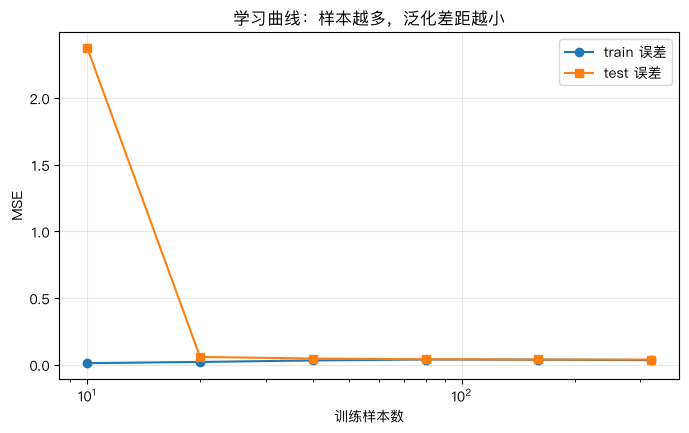

In [4]:
def learning_curve(n_train, deg=5, n_test=2000):
    xs = rng.uniform(-3, 3, n_train)
    ys = np.sin(xs) + 0.2*rng.standard_normal(n_train)
    w = np.polyfit(xs, ys, deg)
    tr_err = np.mean((np.polyval(w, xs) - ys)**2)
    xt = rng.uniform(-3, 3, n_test)
    yt = np.sin(xt) + 0.2*rng.standard_normal(n_test)
    te_err = np.mean((np.polyval(w, xt) - yt)**2)
    return tr_err, te_err

ns = [10, 20, 40, 80, 160, 320]
tr_e = []; te_e = []
for n in ns:
    t1, t2 = learning_curve(n)
    tr_e.append(t1); te_e.append(t2)

plt.figure(figsize=(8, 4.5))
plt.plot(ns, tr_e, 'o-', label='train 误差')
plt.plot(ns, te_e, 's-', label='test 误差')
plt.xscale('log')
plt.xlabel('训练样本数'); plt.ylabel('MSE')
plt.title('学习曲线：样本越多，泛化差距越小')
plt.legend(); plt.grid(alpha=0.3)


## 4. 验证集的使用规范


- val 是"调参时反复看"的曲线，test 是"交卷前只看一次"的分数
- 每次用 val 选超参数，本质上是在对 val 做轻微的过拟合；超参数越多、试得越久，val 越不可信 → 用**嵌套验证**或增大数据集
- **数据泄漏**：归一化统计量、特征选择必须在 train 上算，再应用到 val/test，否则泄漏会让 val/test 虚高


## 5. 实践法则


| 症状 | 诊断 | 处方 |
|------|------|------|
| train≈0，val 高 | 过拟合 | 正则化、更多数据、更小模型 |
| train 高，val 高 | 欠拟合 | 更大模型、更长训练、更小正则 |
| train 高，val 更高 | 数据问题/泄漏 | 检查数据划分与预处理 |

先修"欠拟合"（让 train 降下来），再谈"过拟合"（拉近 val）——顺序别反。


## 课后练习


1. **完整推导**：写出偏差-方差分解的三步（展开、交叉项为零、分别命名）。
2. **噪声项**：把 $\sigma^2$ 从 0.2 改成 0.05 与 0.8，重跑权衡图，观察最优复杂度的移动方向。
3. **bootstrap**：用自助法（重采样）估计 $\mathrm{Var}[\hat f]$，与解析法对比。
4. **学习曲线**：把次数从 5 改成 9，观察 train/test 曲线的起点与收敛值变化。
5. **思考**：为什么说"深度学习过拟合时，增大数据往往比增大正则化更有效"？
